In [1]:
import warnings
warnings.filterwarnings("ignore")

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import os

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature

from sklearn.cluster import KMeans

In [11]:
df= pd.read_csv("df_data.csv").dropna()

# print(df['station_id'].nunique()) # 263

df_plotter = df.drop(['Unnamed: 0','forecast_data','observed_data','time_UTC_dt'], axis=1)
df_plotter['time_UTC']= pd.to_datetime(df_plotter['time_UTC'])

plotter_pivot_df = df_plotter.pivot_table(values='offset', index='time_UTC', columns='station_id', aggfunc='first')
station_counts = df['station_id'].value_counts()
df = df[df['station_id'].isin(station_counts[station_counts == 167].index)].reset_index()

# print(df['station_id'].nunique()) # 204

df_filtered = df[df['station_id'] != 85670.0]
df['station_id'] = df_filtered['station_id'].astype(str)

# print(df['station_id'].nunique()) # 203

### Clustering

In [17]:
unique_stations = df[['station_id', 'x', 'y']].drop_duplicates()
unique_df = pd.DataFrame(unique_stations, columns=['station_id', 'x', 'y'])

nclusters= int(len(unique_df)*0.1)

kmeans = KMeans(n_clusters= nclusters, random_state=42)
unique_df['cluster_id'] = kmeans.fit_predict(unique_df[['x','y']])

unique_df= unique_df.sort_values('cluster_id')

import matplotlib.colors as mcolors

cmap = plt.cm.get_cmap('Set1')
colors = [cmap(i) for i in range(8)]
colors_hex = [mcolors.rgb2hex(c) for c in colors]
 
cluster_colors = {cluster_id: colors_hex[cluster_id % 8] for cluster_id in unique_df['cluster_id']}
unique_df['color'] = unique_df['cluster_id'].map(cluster_colors)

In [18]:
unique_df

,station_id,x,y,cluster_id,color
33400,9752235.0,-65.302997,18.299317,0,#e41a1c
33233,9751639.0,-64.921000,18.335833,0,#e41a1c
33066,9751401.0,-64.753799,17.694700,0,#e41a1c
32899,9751381.0,-64.727833,18.312609,0,#e41a1c
32732,9751364.0,-64.698390,17.752867,0,#e41a1c
...,...,...,...,...,...
25885,8726724.0,-82.833000,27.978306,19,#984ea3
25718,8726674.0,-82.421389,27.923056,19,#984ea3
25551,8726520.0,-82.626900,27.760610,19,#984ea3
8851,2310747.0,-82.623889,28.906389,19,#984ea3


In [23]:
def mapper():
    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.Mercator())
    
    # Adding features to the map
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, edgecolor='black')
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.set_extent([-100, -64, 16, 47], crs=ccrs.PlateCarree())

    # Setting map background color
    ax.stock_img()  # This adds a background image with natural features
    ax.add_feature(cfeature.LAND, color='0.8')  # Adding land with grey color
    ax.add_feature(cfeature.OCEAN, color='lightblue')  # Adding ocean with light blue color
    ax.add_feature(cfeature.LAKES, color='lightblue')  # Adding lakes with light blue color
    
    lake_borders = NaturalEarthFeature(category='physical', name='lakes', scale='10m', edgecolor='black', facecolor='none')
    ax.add_feature(lake_borders)
    
    return ax

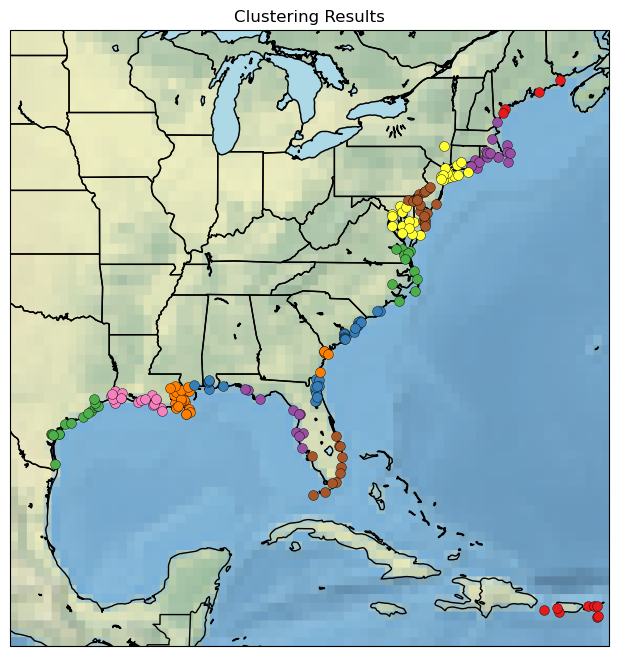

In [24]:
ax= mapper()

for i in range(len(unique_df)):
    x = unique_df['x'].iloc[i]
    y = unique_df['y'].iloc[i]
    ax.scatter(x, y, marker='o', color= unique_df['color'].iloc[i],
               edgecolors='black', linewidths=0.3, zorder= 10, s= 50, transform=ccrs.PlateCarree())    

plt.title('Clustering Results')
plt.show()

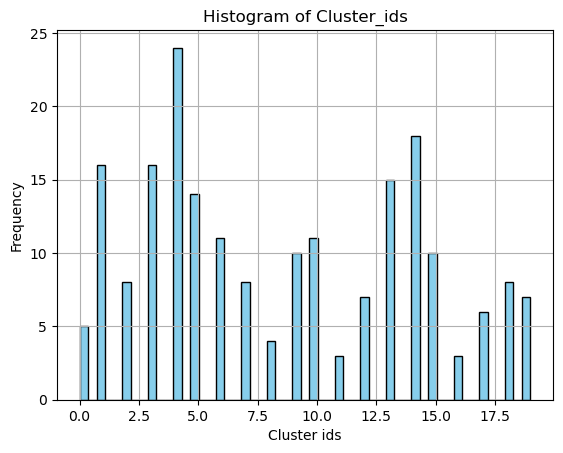

In [22]:
plt.hist(unique_df['cluster_id'], bins=53, color='skyblue', edgecolor='black')  
plt.xlabel('Cluster ids')
plt.ylabel('Frequency')
plt.title('Histogram of Cluster_ids')
plt.grid(True)
plt.show()

In [28]:
unique_df= unique_df[unique_df['cluster_id']==9]

training_stations = unique_df.head(8)
testing_stations = unique_df.tail(2)

In [49]:
training_df=  df[df['station_id'].isin(train_ids)]

testing_df= df[df['station_id'].isin(test_ids)]

In [51]:
training_df.to_csv('training_df.csv', index=False)
testing_df.to_csv('testing_df.csv', index=False)